# Unique Solution of Schochastic Fixed-Point Equation

This notebook is to check conjectures in proving that the SFPE
$$X \stackrel{d}{=} I(U^{\alpha}X^{(1)} + (1-U)^{\alpha}X^{(2)}) + J\max(U^{\alpha}X^{(1)}, (1-U)^{\alpha}X^{(2)})$$

has a unique solution $(\alpha^*, X_{\alpha^*})$ such that $\mathbb{E}[X_{\alpha^*}] = 1$.

The classical contraction method does not work: because of the sum, $W_p$ does not work; because of the max, $\zeta_p$ does not work.

In [2]:
from typing import Literal

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#### Monte-Carlo Simulation

In [15]:
class MeanOneGenerator:
    """
    Generate random distributions of mean 1
    """
    def __init__(self, size=100000):
        self.size = size
        # Bank of base distributions with random shape parameters
        self.distribution_bank = [
            (stats.lognorm, {'s': lambda: np.random.uniform(0.5, 2.0)}),  # Heavy right tail
            (stats.gamma, {'a': lambda: np.random.uniform(0.5, 5.0)}),    # Flexible skew
            (stats.weibull_min, {'c': lambda: np.random.uniform(0.5, 2.0)}), # Extreme value
            (stats.halfcauchy, {'loc': lambda: 0, 'scale': lambda: 1})    # Extreme heavy tail
        ]

    def generate_uniform_shape(self):
      """Generates a uniform distribution with random variance, projected to mean 1."""
      
      width = np.random.uniform(low=0.1, high=0.99)
      
      Z = np.random.uniform(low=1.0 - width, high=1.0 + width, size=self.size)
      X = Z / np.mean(Z) 
    
      return X, "Uniform", {"low": 1.0 - width, "high": 1.0 + width}
    
    def generate_custom_shape(self, shape: Literal["uniform", "lognorm", "gamma", "dirac"]):
        if shape == "uniform":
            return self.generate_uniform_shape()
        elif shape == "dirac":
            # Generate a Dirac delta distribution (all values are 1)
            X = np.ones(self.size)
            return X, "Dirac", {}
        else:
            dist_class, param_generators = self.distribution_bank[{"lognorm": 0, "gamma": 1, "weibull_min": 2, "halfcauchy": 3}[shape]]
            
            # Evaluate the random parameters
            params = {k: v() for k, v in param_generators.items()}
            
            # Generate the unconstrained array (Z)
            Z = dist_class.rvs(**params, size=self.size)
            
            # Project to Mean = 1 (X)
            empirical_mean = np.mean(Z)
            X = Z / empirical_mean
            
            return X, dist_class.name, params
        
    def generate_random_shape(self):
        """Selects a random distribution and randomizes its shape parameters."""
        
        dist_class, param_generators = self.distribution_bank[np.random.randint(0, len(self.distribution_bank))]
        
        # Evaluate the random parameters
        params = {k: v() for k, v in param_generators.items()}
        
        # Generate the unconstrained array (Z)
        Z = dist_class.rvs(**params, size=self.size)
        
        # Project to Mean = 1 (X)
        empirical_mean = np.mean(Z)
        X = Z / empirical_mean
        
        return X, dist_class.name, params

In [4]:
# Sample an iid empirical distribution from another empirical distribution (like a bootstrap)
def sample_from_empirical(X):
    return np.random.choice(X, size=len(X), replace=True)

In [5]:
def plot_distribution(
        particle_array, 
        title="Empirical Distribution", 
        bins=100, clip_percentile=100, 
        log_y=False, show_bins=False, show_kde=True):
    """
    Plots the distribution of a 1D array of particles with optional bins and KDE.
    """
    clean_array = particle_array[np.isfinite(particle_array)]
    
    if clip_percentile < 100:
        max_val = np.percentile(clean_array, clip_percentile)
        view_array = clean_array[clean_array <= max_val]
        clip_note = f" (X-axis clipped at {clip_percentile}th percentile)"
    else:
        view_array = clean_array
        clip_note = ""

    plt.figure(figsize=(10, 6))
    
    if show_bins and show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=True, 
                          stat="density", alpha=0.4)
                        
    elif show_bins and not show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=False, 
                          stat="density", alpha=0.6)
                          
    elif not show_bins and show_kde:
        ax = sns.kdeplot(view_array, fill=True, alpha=0.3, linewidth=2)
        
    else:
        print("Error: Must choose to show either bins, KDE, or both.")
        return

    if log_y:
        ax.set_yscale('log')
        plt.ylabel("Density (Log Scale)")
    else:
        plt.ylabel("Density")
        
    plt.xlabel("Particle Value")
    plt.title(title + clip_note, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    emp_mean = np.mean(clean_array)
    plt.axvline(emp_mean, color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean = {emp_mean:.4f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
import numpy as np

def wasserstein(X, Y, p=1):

    X = np.asarray(X)
    Y = np.asarray(Y)
    
    if len(X) != len(Y):
        raise ValueError(f"Distributions must have the same length. "
                         f"Got len(X)={len(X)} and len(Y)={len(Y)}.")
  
    X_sorted = np.sort(X)
    Y_sorted = np.sort(Y)
    distance = np.power(np.mean(np.abs(X_sorted - Y_sorted)**p), 1/p)
    
    return distance

In [7]:
# Test
generator = MeanOneGenerator(size=50000)
X, name, params = generator.generate_random_shape()

print(f"Base Shape: {name} | Parameters: {params}")
print(f"Empirical Mean: {np.mean(X):.10f}")
print(f"Empirical Variance: {np.var(X):.5f}")

Base Shape: lognorm | Parameters: {'s': 1.1995421062090275}
Empirical Mean: 1.0000000000
Empirical Variance: 3.32690


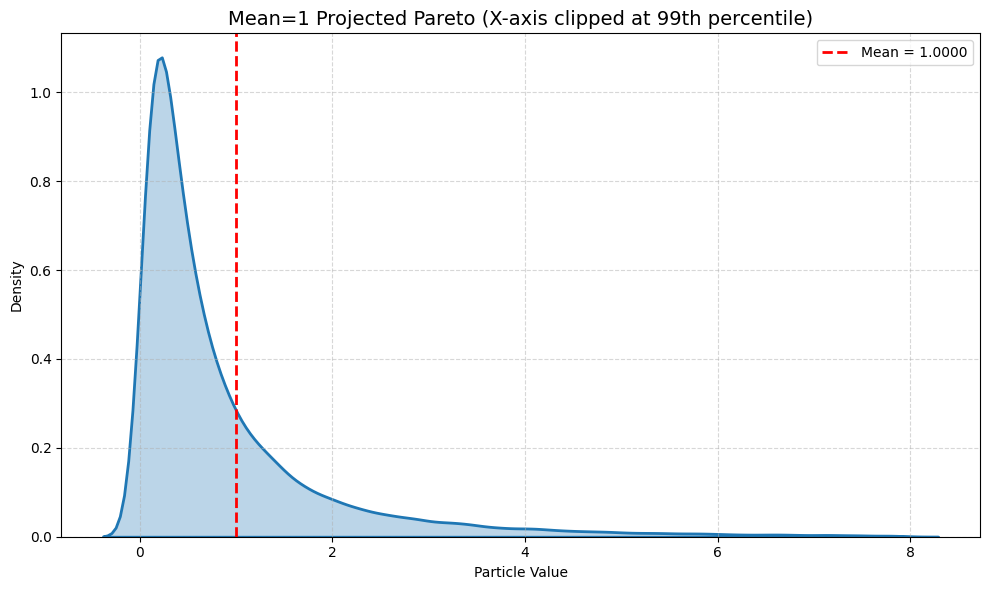

In [8]:
plot_distribution(X, title="Mean=1 Projected Pareto", clip_percentile=99)

#### Check convergence to an $\alpha$ and unique limit distribution



In [9]:
def apply_T(X, u,v, alpha):
    # Sample independent pairs
    X1 = sample_from_empirical(X)
    X2 = sample_from_empirical(X)
    
    # Sample U, I and J
    U = np.random.uniform(0, 1, size=len(X))
    R = np.random.uniform(0, 1, size=len(X))
    
    I = (R < u).astype(np.float64)
    J = ((R >= u) & (R < u + v)).astype(np.float64)
    
    # Apply the operator T_alpha
    term1 = (U**alpha) * X1
    term2 = ((1 - U)**alpha) * X2
    
    T_X = I * (term1 + term2) + J * np.maximum(term1, term2)

    return T_X

def apply_S(X, u, v, alpha):
    Y = apply_T(X, u, v, alpha)
    return Y / np.mean(Y)

In [10]:
def cummulative_mean(alpha, u, v, X, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha(u, v, X_init, lower, upper, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Cumulative Mean':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_mean:<15.5f}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X


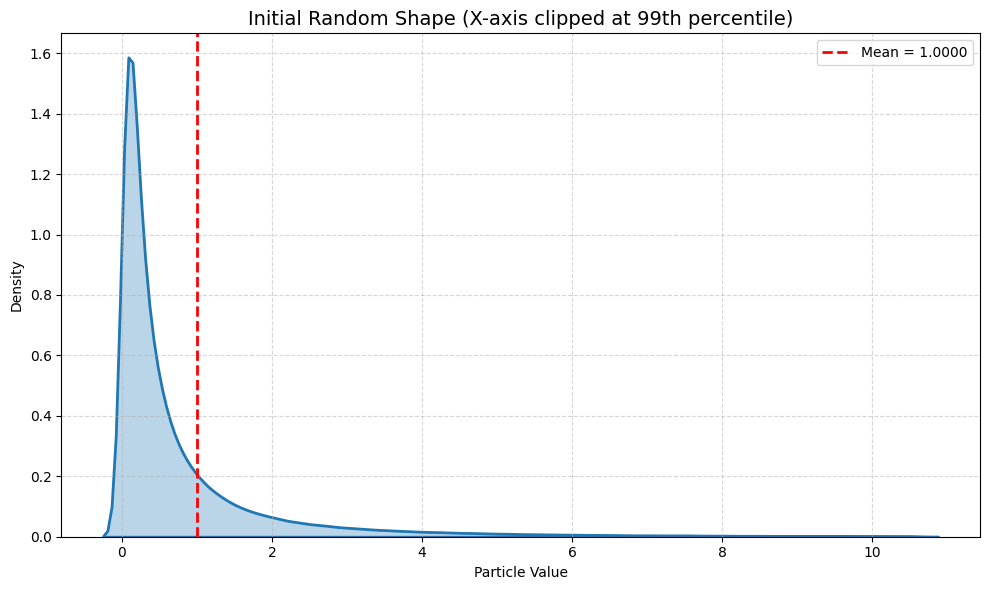

Searching for alpha* for u=0.6, v=0.2
Step  | Alpha Estimate  | Cumulative Mean
----------------------------------------
1     | 0.50000         | 1.01291        
2     | 0.55000         | 0.98243        
3     | 0.52500         | 0.99752        
4     | 0.51250         | 1.00554        
5     | 0.51875         | 1.00133        
6     | 0.52188         | 0.99918        
7     | 0.52031         | 1.00039        
8     | 0.52109         | 0.99995        
9     | 0.52070         | 1.00011        
10    | 0.52090         | 0.99987        
11    | 0.52080         | 0.99978        
12    | 0.52075         | 1.00017        
13    | 0.52078         | 1.00012        
14    | 0.52079         | 1.00037        
15    | 0.52079         | 1.00007        
16    | 0.52080         | 0.99992        
17    | 0.52080         | 1.00006        
18    | 0.52080         | 0.99999        
19    | 0.52080         | 1.00007        
20    | 0.52080         | 1.00025        
21    | 0.52080         | 0.99997      

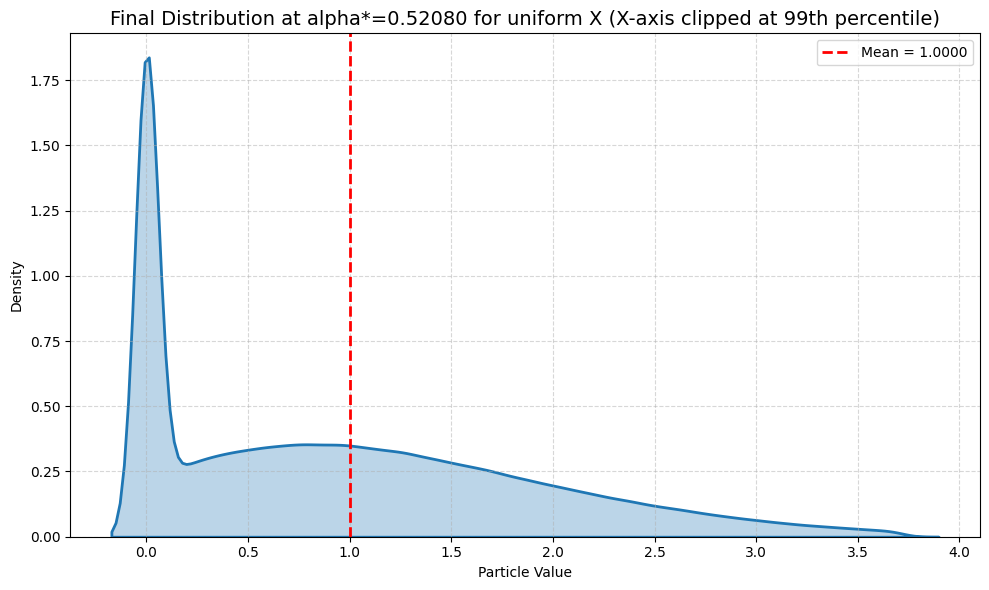

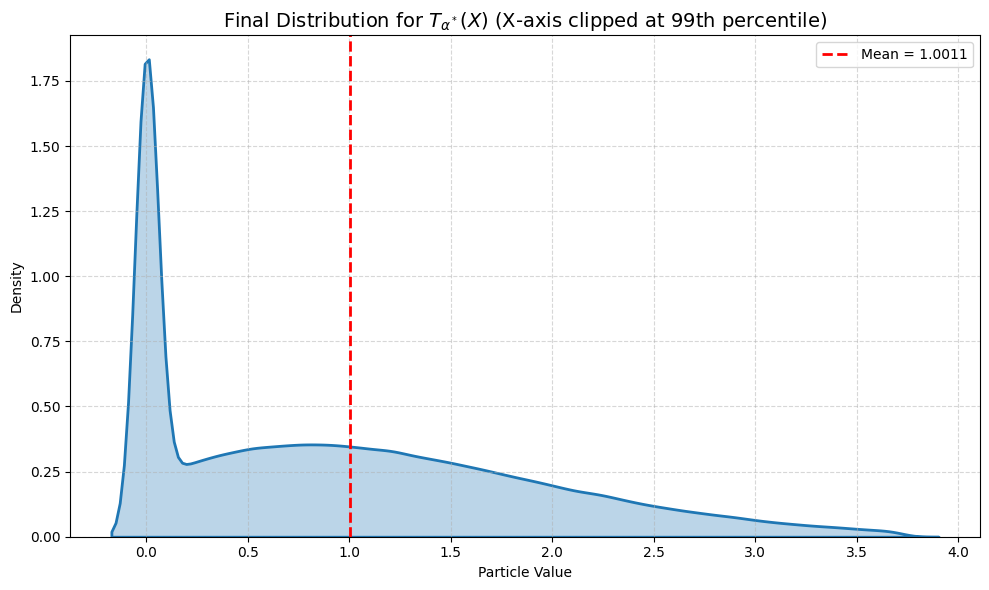

In [17]:
generator = MeanOneGenerator(size=1000000)
X_init,_,_ = generator.generate_random_shape()
plot_distribution(X_init, title="Initial Random Shape", clip_percentile=99)

u, v = 0.6, 0.2

lower = 2*u + v - 1
upper  = 2*(u+v) - 1

alpha_star, X_final = find_alpha(u, v, X_init, lower=lower, upper=upper, max_steps=30)

plot_distribution(X_final, title=f"Final Distribution at alpha*={alpha_star:.5f} for uniform X", clip_percentile=99)
plot_distribution(apply_T(X_final, u, v, alpha_star), title=f"Final Distribution for $T_{{\\alpha^*}}(X)$", clip_percentile=99)

#### Check if that $\alpha$ may be the true power.

##### Compute distribution of $Y_n$

$$Y_{n} = I\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_2=1.$$

Given that the subscripts are for independent copies. The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I+J\le 1$ and $u+v\le 1$, and they are inpependent of all $Y^{(j)}_i$.

In [30]:
def compute_Yn(max_N, u, v):

    pmfs = [np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - u - v

    for n in range(2, max_N + 1):
        if n % 10 == 0:
            print(f"Computing up to n={n}...")
            
        current_pmf = np.zeros(n)
        
        # U_n is uniform over {0, ..., n-1}
        # Evaluate up to floor(n/2) and double the weights for symmetry
        for k in range((n + 1) // 2):
            j = n - 1 - k
            weight = 2.0 if k != j else 1.0
            
            # Concatenation: convolution
            conv_pmf = np.convolve(pmfs[k], pmfs[j])
            concat_pmf = np.zeros(len(conv_pmf) + 1)

            # Shift by 1 for the "+ 1"
            concat_pmf[1:] = conv_pmf  
            
            length_c = min(len(concat_pmf), n)
            current_pmf[:length_c] += weight * u * concat_pmf[:length_c]
            
            # Alternation
            len_k = len(cdfs[k])
            len_j = len(cdfs[j])
            max_len = max(len_k, len_j)
            
            cdf_k_ext = np.ones(max_len)
            cdf_k_ext[:len_k] = cdfs[k]
            
            cdf_j_ext = np.ones(max_len)
            cdf_j_ext[:len_j] = cdfs[j]
            
            cdf_max = cdf_k_ext * cdf_j_ext
            
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), n)
            current_pmf[:length_m] += weight * v * pmf_max[:length_m]

        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # Termination
        current_pmf[0] += termination_prob
        
        # Correct floating-point inaccuracies
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))
    
    expectations = [np.sum(pmf * np.arange(len(pmf))) for pmf in pmfs]
        
    return pmfs, cdfs, expectations

Computing up to n=10...
Computing up to n=20...
Computing up to n=30...
Computing up to n=40...
Computing up to n=50...
Computing up to n=60...
Computing up to n=70...
Computing up to n=80...
Computing up to n=90...
Computing up to n=100...
Computing up to n=110...
Computing up to n=120...
Computing up to n=130...
Computing up to n=140...
Computing up to n=150...
Computing up to n=160...
Computing up to n=170...
Computing up to n=180...
Computing up to n=190...
Computing up to n=200...
Computing up to n=210...
Computing up to n=220...
Computing up to n=230...
Computing up to n=240...
Computing up to n=250...
Computing up to n=260...
Computing up to n=270...
Computing up to n=280...
Computing up to n=290...
Computing up to n=300...
Computing up to n=310...
Computing up to n=320...
Computing up to n=330...
Computing up to n=340...
Computing up to n=350...
Computing up to n=360...
Computing up to n=370...
Computing up to n=380...
Computing up to n=390...
Computing up to n=400...
Computing

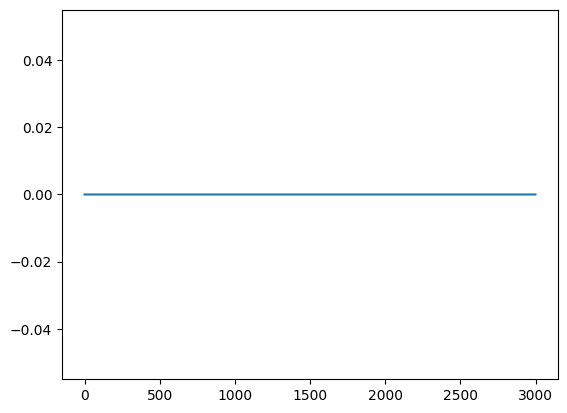

In [ ]:
# Costly
pmfs, cdfs, expectations = compute_Yn(max_N=3000, u=0.5, v=0.3)
# plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

In [64]:
# Save computations
from pathlib import Path
import numpy as np

# Determine an output directory called 'distributions'.
# Try several likely locations relative to the current working directory.
cwd = Path.cwd()
candidates = [
    cwd / 'distributions',
    cwd.parent / 'distributions',
    cwd.parent.parent / 'distributions',
]
out_dir = next((p for p in candidates if p.exists()), candidates[1])
out_dir.mkdir(parents=True, exist_ok=True)

# Save pmfs (one file per n)
for n, pmf in enumerate(pmfs):
    fname = out_dir / f'pmf_{n}.txt'
    np.savetxt(fname, pmf, fmt='%.18e')

# Save cdfs (one file per n)
for n, cdf in enumerate(cdfs):
    fname = out_dir / f'cdf_{n}.txt'
    np.savetxt(fname, cdf, fmt='%.18e')

# Save expectations to a single text file
exp_file = out_dir / 'expectations.txt'
with exp_file.open('w') as fh:
    for n, e in enumerate(expectations):
        fh.write(f"{n}	{e:.18e}\n")

print(f'Wrote {len(pmfs)} pmf files, {len(cdfs)} cdf files, and {len(expectations)} expectations to {out_dir}')

Wrote 3001 pmf files, 3001 cdf files, and 3001 expectations to d:\Projects\m2-bezout\internship\src\notebooks\distributions


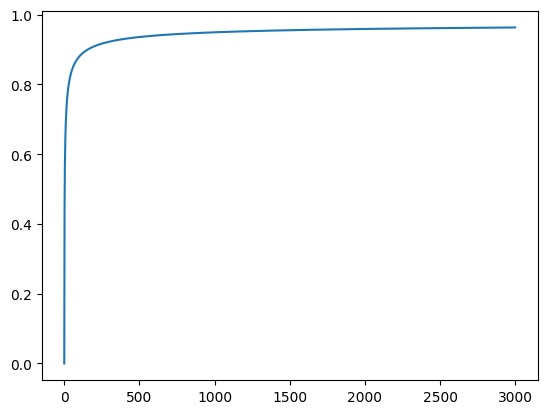

In [63]:
plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

#### Check if $T_{\alpha^*}$ has a unique fixed point

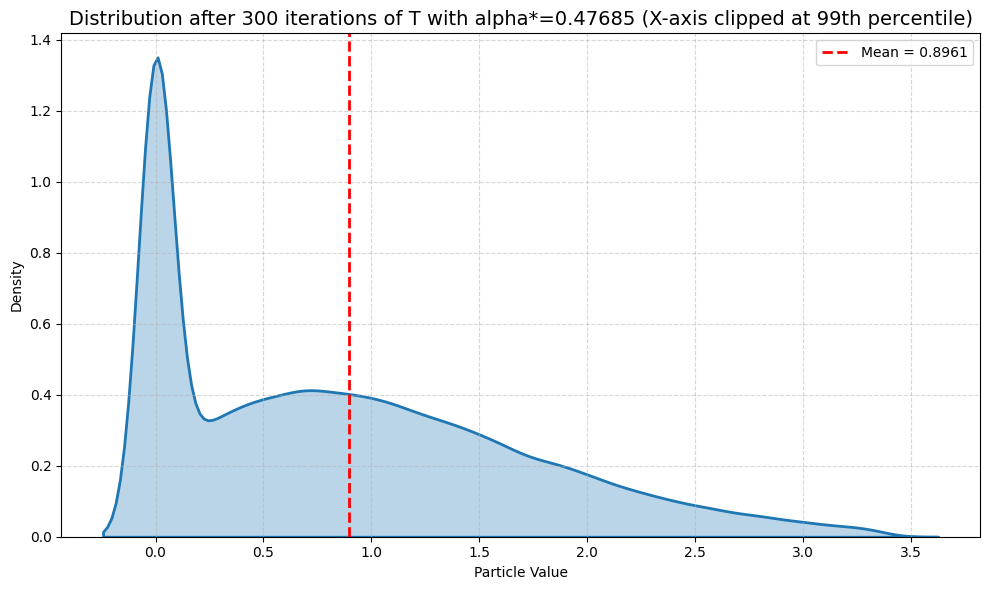

In [75]:
alpha_star = 0.47685
generator = MeanOneGenerator(size=100000)
X_init,_,_ = generator.generate_uniform_shape()

X = X_init

for _ in range(300):
    X = apply_T(X, u, v, alpha_star)

plot_distribution(X, title=f"Distribution after 300 iterations of T with alpha*={alpha_star:.5f}", clip_percentile=99)

#### Check if $S_\alpha = \dfrac{T_\alpha}{\mathbb{E}[T_\alpha]}$ has a fixed point

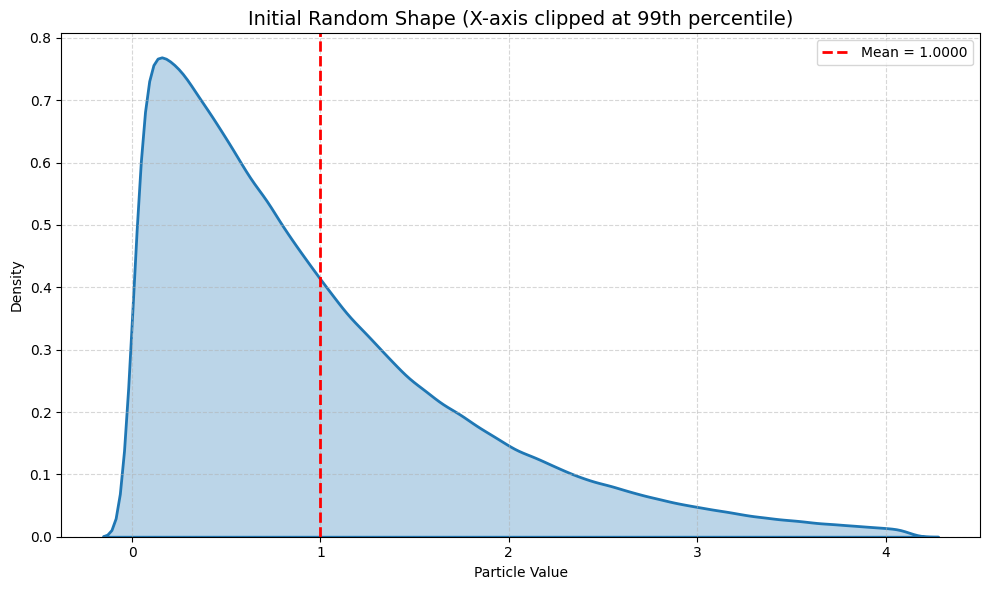

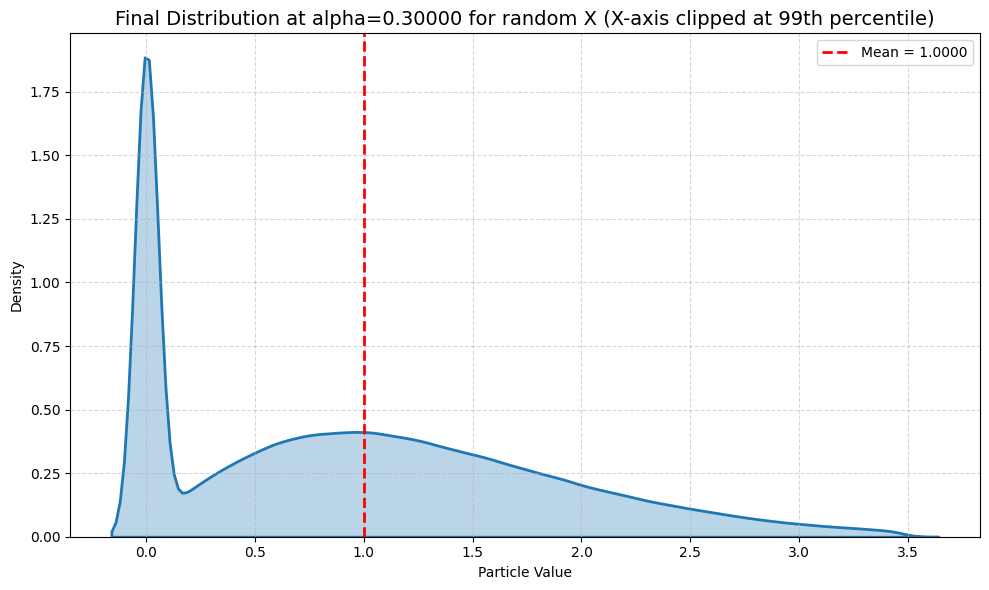

In [12]:
generator = MeanOneGenerator(size=1000000)

X_init,_,_ = generator.generate_random_shape()
plot_distribution(X_init, title="Initial Random Shape", clip_percentile=99)

alpha = 0.3
u, v = 0.5, 0.3

X = X_init

for _ in range(20):
    X = apply_S(X, u, v, alpha)

plot_distribution(X, title=f"Final Distribution at alpha={alpha:.5f} for random X", clip_percentile=99)

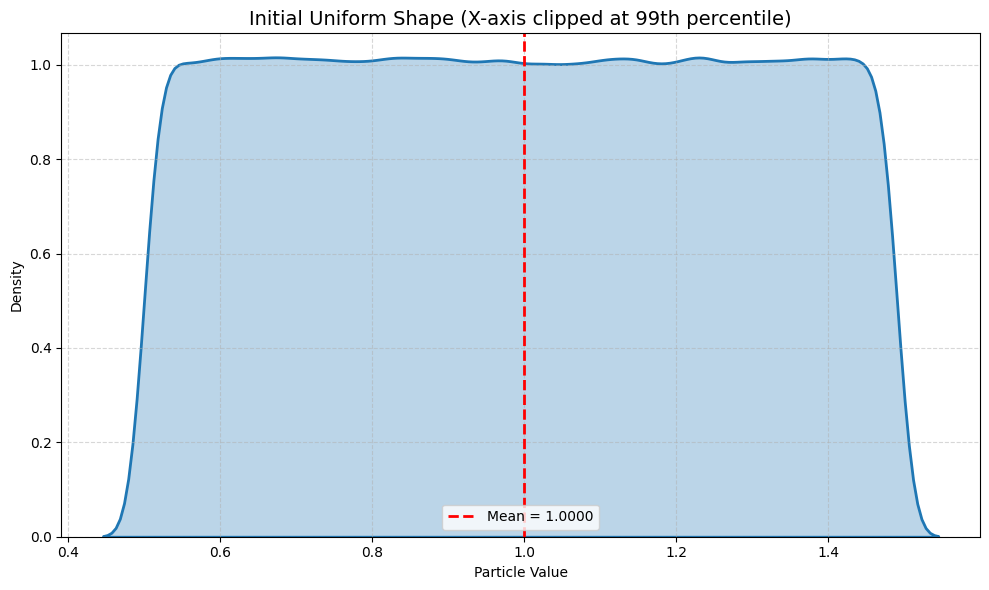

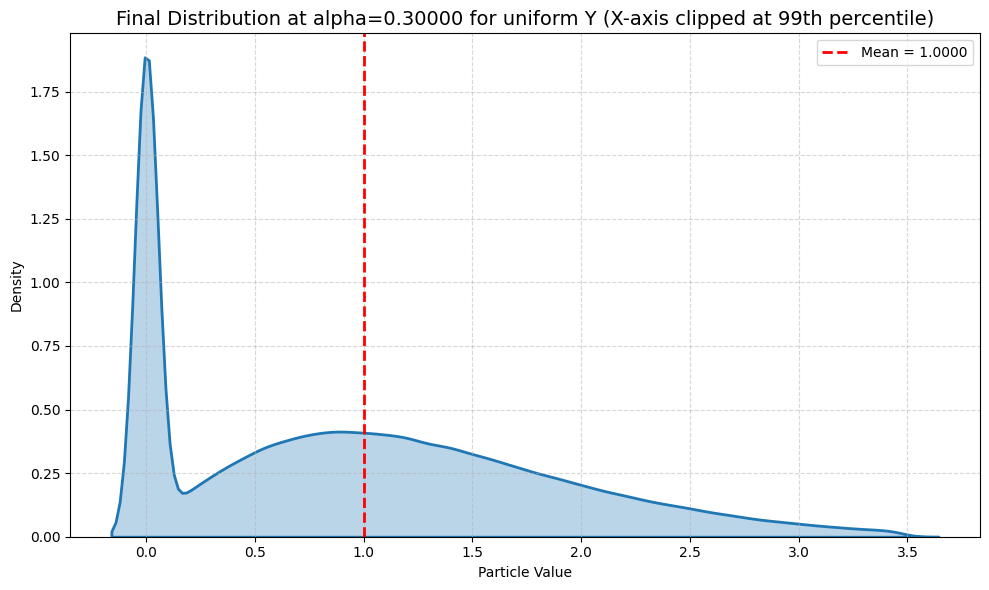

In [13]:
Y_init,_,_ = generator.generate_uniform_shape()
plot_distribution(Y_init, title="Initial Uniform Shape", clip_percentile=99)

Y = Y_init

for _ in range(20):
    Y = apply_S(Y, u, v, alpha)

plot_distribution(Y, title=f"Final Distribution at alpha={alpha:.5f} for uniform Y", clip_percentile=99)

#### Check if $S_\alpha$ is a contraction in the $W_1$ metric.

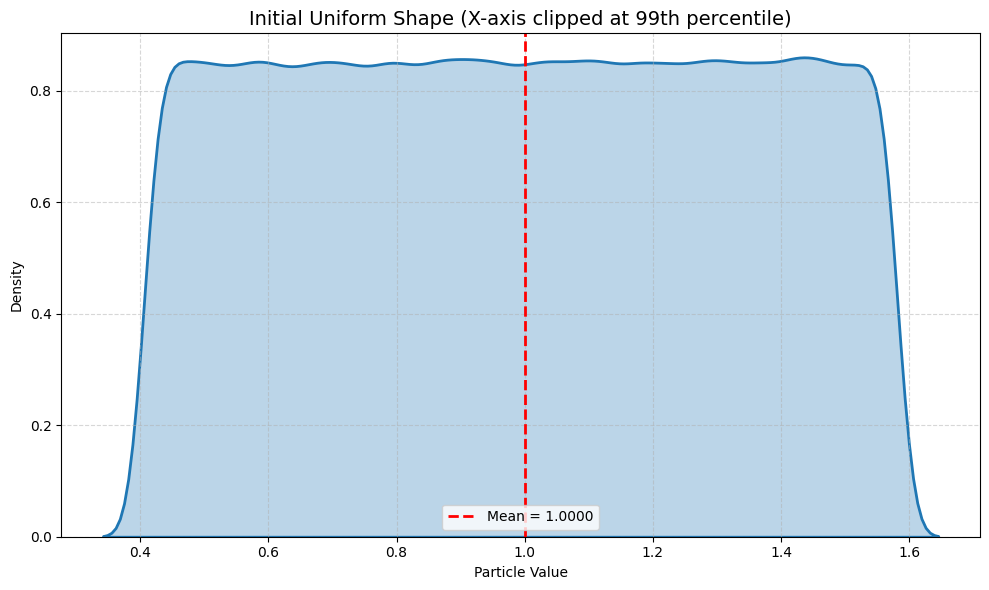

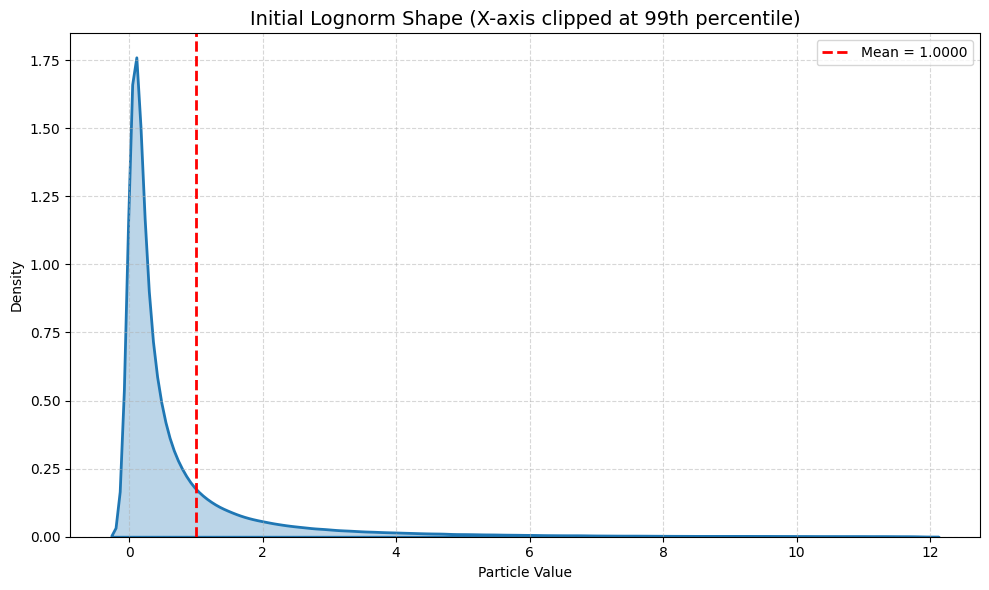

Wp-Contraction of S_alpha (alpha=0.4, u=0.5, v=0.3)
---------------------------------------------------------------------------
Generation      | Distance W_s(X, Y)        | Contraction Ratio   
---------------------------------------------------------------------------
Gen 00 -> 01  | 1.007568                  | 0.829322            
Gen 01 -> 02  | 0.835598                  | 0.830336            
Gen 02 -> 03  | 0.693827                  | 0.828467            
Gen 03 -> 04  | 0.574813                  | 0.831662            
Gen 04 -> 05  | 0.478050                  | 0.834275            
Gen 05 -> 06  | 0.398825                  | 0.830972            
Gen 06 -> 07  | 0.331413                  | 0.825240            
Gen 07 -> 08  | 0.273495                  | 0.819812            
Gen 08 -> 09  | 0.224215                  | 0.818883            
Gen 09 -> 10  | 0.183606                  | 0.809322            
Gen 10 -> 11  | 0.148596                  | 0.800664            
Gen 11 -> 12  

In [40]:
u=0.5
v=0.3
alpha=0.4

generator = MeanOneGenerator(size=1000000)
X,_,_ = generator.generate_uniform_shape()
Y,_,_ = generator.generate_custom_shape("lognorm")

plot_distribution(X, title="Initial Uniform Shape", clip_percentile=99)
plot_distribution(Y, title="Initial Lognorm Shape", clip_percentile=99)

print(f"Wp-Contraction of S_alpha (alpha={alpha}, u={u}, v={v})")
print("-" * 75)
print(f"{'Generation':<15} | {'Distance W_s(X, Y)':<25} | {'Contraction Ratio':<20}")
print("-" * 75)

for i in range(1, 30):
    
    current_dist = wasserstein(X, Y)
    
    X_next = apply_S(X, u, v, alpha)
    Y_next = apply_S(Y, u, v, alpha)
    
    next_dist = wasserstein(X_next, Y_next, p=1)
    
    ratio = next_dist / current_dist
    
    print(f"Gen {i-1:02d} -> {i:02d}  | {current_dist:<25.6f} | {ratio:<20.6f}")
    
    X, Y = X_next, Y_next

$X_n = I\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n} + \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n} + \dfrac{1}{n^\alpha}\right) + J\max\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n}, \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n}\right)$

Here $I,J$ are mutually exclusive Bernoulli and $U_n$ is uniform over $\{0,\ldots,n-1\}$. Let $X_0=X_1=0$. 

The paramemter $\alpha$ is chosen such that the fixed-point equation
$$X \stackrel{d}{=} I(U^\alpha X^{(1)} + (1-U)^{\alpha} X^{(2)}) + J\max(U^\alpha X^{(1)}, (1-U)^{\alpha} X^{(2)})$$

has a unique mean-1 solution $X$. Here $X^{(1)}$ and $X^{(2)}$ are iid copies of $X$ and $U$ is uniform over $[0,1]$.

In [57]:
def pmf_to_particles(pmf_array, size):
    """
    Converts a PMF array into a corresponding array of particles.
    """
    possible_values = np.arange(len(pmf_array))
    normalized_pmf = pmf_array / np.sum(pmf_array)
    
    particles = np.random.choice(possible_values, size=size, p=normalized_pmf)
    
    return particles

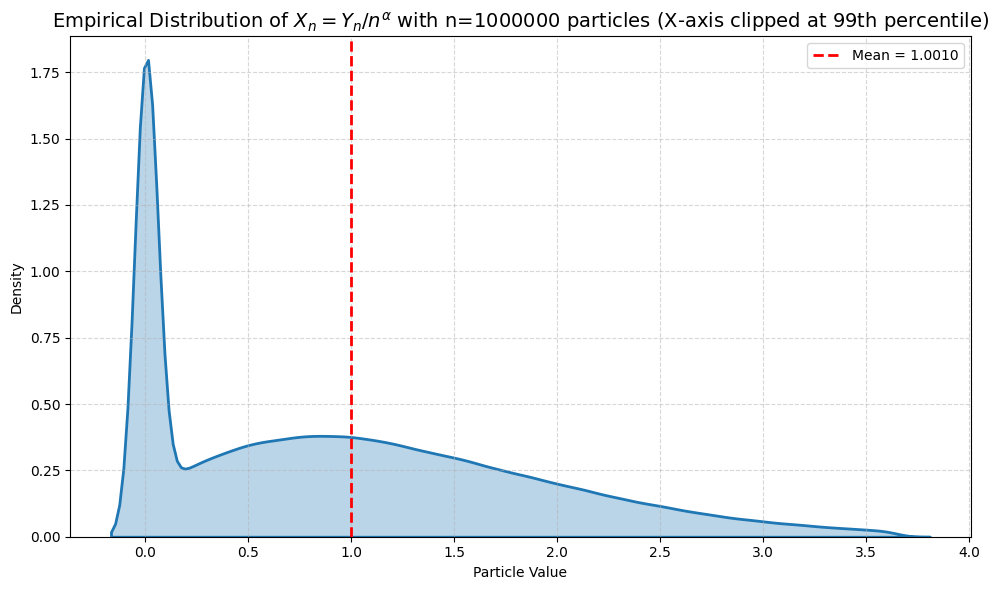

In [59]:
n = 3000
N = 1000000

out_dir = Path.cwd() / 'distributions'
pmf_file = out_dir / f'pmf_{n}.txt'

Yn_pmf = np.loadtxt(pmf_file)
EY_n = np.sum(np.arange(len(Yn_pmf)) * Yn_pmf)

alpha_star = 0.47685
normalizing_constant = EY_n/(n ** alpha_star)

Yn = pmf_to_particles(Yn_pmf, size=N)
Xn = Yn / (n ** alpha_star * normalizing_constant)

plot_distribution(Xn, title=f"Empirical Distribution of $X_n = Y_n / n^\\alpha$ with n={N} particles", 
                  bins=100, clip_percentile=99, show_kde=True)

In [68]:
import scipy.integrate as integrate

def compute_H(p, u, v, alpha):
    """
    Computes the contraction function H(p, alpha) for a given p.
    
    Parameters:
    p (float): The Wasserstein parameter / power.
    u (float): Probability of the sum operation (I).
    v (float): Probability of the max operation (J).
    alpha (float): The scaling exponent.
    
    Returns:
    float: The evaluated value of H(p, alpha).
    """
    # 1. Define the integrand: (x^alpha + (1-x)^alpha)^p
    def integrand(x):
        return (x**alpha + (1 - x)**alpha)**p
    
    # 2. Compute the integral from 0 to 1
    # quad returns a tuple: (value_of_integral, estimate_of_absolute_error)
    integral_value, error_estimate = integrate.quad(integrand, 0, 1, epsrel=1e-12)
    
    # 3. Add the maximum term component
    max_term = (2 * v) / (alpha * p + 1)
    
    # 4. Combine for the final result
    H_value = u * integral_value + max_term
    
    return H_value


# Example parameters
u = 0.5
v = 0.3

lower = 0
upper = 1

alpha = 0.5
p=1

print(f"Iteration | alpha | H(p={p}, alpha)")

for _ in range(20):
    mid = (lower + upper) / 2
    H_mid = compute_H(p, u, v, mid)

    if H_mid < 1:
        upper = mid
    else:        
        lower = mid

    print(f"{_+1:9d} | {mid:.6f} | {H_mid:.6f}")

    alpha = mid



Iteration | alpha | H(p=1, alpha)
        1 | 0.500000 | 1.066667
        2 | 0.750000 | 0.914286
        3 | 0.625000 | 0.984615
        4 | 0.562500 | 1.024000
        5 | 0.593750 | 1.003922
        6 | 0.609375 | 0.994175
        7 | 0.601562 | 0.999024
        8 | 0.597656 | 1.001467
        9 | 0.599609 | 1.000244
       10 | 0.600586 | 0.999634
       11 | 0.600098 | 0.999939
       12 | 0.599854 | 1.000092
       13 | 0.599976 | 1.000015
       14 | 0.600037 | 0.999977
       15 | 0.600006 | 0.999996
       16 | 0.599991 | 1.000006
       17 | 0.599998 | 1.000001
       18 | 0.600002 | 0.999999
       19 | 0.600000 | 1.000000
       20 | 0.599999 | 1.000000
